# Stage 8 — Improved Semi-Supervised Learning (Issue #4)

**Motivation:** The confidence-thresholding and self-training approaches in Stage 6 both degraded the supervised baseline (F1-macro 0.8802). The two root causes were:
1. Severe class skew in pseudo-labels (14:1 spam:legit ratio at threshold 0.10)
2. Over half the unlabeled tokens fell in the ambiguous confidence band — the model was genuinely uncertain about them

**Two alternative approaches proposed in Issue #4:**

- **Approach A — Isolation Forest:** Train an anomaly detector on confirmed spam features to score unlabeled tokens without relying on the classifier's confidence. IF operates on the feature distribution directly, not on predicted probabilities.
- **Approach B — Label Spreading:** Graph-based semi-supervised learning. Construct a k-NN graph over all tokens using their behavioral features, then propagate known labels through the graph topology. Tokens near labeled spam become spam; tokens near labeled legit become legit.
- **Approach C — Sender-Network Propagation:** True graph-based propagation using the actual transfer network. Tokens that share senders with known spam tokens receive a spam-sender score and are pseudo-labeled based on that network signal.

All three approaches use existing data only.

## 1. Imports & Setup

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from scipy.sparse import csr_matrix

from sklearn.ensemble import IsolationForest
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.base import clone
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Supervised Artifacts & Test Set

In [2]:
best_model   = joblib.load('models/best_model.joblib')
FEATURE_COLS = joblib.load('data/processed/feature_cols.joblib')

train_u = pd.read_parquet('data/processed/train_unscaled.parquet')
X_train = train_u[FEATURE_COLS].values
y_train = train_u['label'].astype(int).values

test_u  = pd.read_parquet('data/processed/test_unscaled.parquet')
X_test  = test_u[FEATURE_COLS].values
y_test  = test_u['label'].astype(int).values

best_params = best_model.get_params()
best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})

print(f'Train: {len(y_train):,}  (spam={( y_train==0).sum()}, legit={(y_train==1).sum()})')
print(f'Test:  {len(y_test):,}   (spam={( y_test==0).sum()},  legit={(y_test==1).sum()})')
print(f'Spam ratio in train: {(y_train==0).mean():.3f}')

Train: 2,524  (spam=1405, legit=1119)
Test:  541   (spam=301,  legit=240)
Spam ratio in train: 0.557


## 3. Rebuild Token Features & Unlabeled Pool

Identical pipeline to previous stages — rebuild all 12,356 tokens, extract the 8,750 unlabeled.

In [3]:
df_transfers = pd.read_parquet('data/transfers_20000000.parquet', engine='pyarrow')
df_account   = pd.read_csv('data/account_labels.csv')
df_token     = pd.read_csv('data/token_labels.csv')
print(f'Transfers: {df_transfers.shape}')

Transfers: (3654710, 15)


In [4]:
verified_addresses = set(
    df_token[df_token['Address'].str.startswith('0x', na=False)]['Address'].str.lower()
)
verified_symbol_map = (
    df_token[df_token['Address'].str.startswith('0x', na=False)]
    .set_index('Symbol')['Address'].str.lower().to_dict()
)

df_tok = df_transfers[
    df_transfers['category'].isin(['erc20', 'token', 'erc721', 'erc1155', 'specialnft'])
].copy()
df_tok['contract_addr'] = df_tok['rawContract.address'].str.lower()
df_tok['asset_upper']   = df_tok['asset'].str.upper()
df_tok['block_int']     = df_tok['blockNum'].apply(
    lambda x: int(x, 16) if isinstance(x, str) else x
)
df_tok['is_verified']   = df_tok['contract_addr'].isin(verified_addresses).astype(int)

def check_collision(row):
    sym, addr = row['asset_upper'], row['contract_addr']
    if not isinstance(sym, str) or not isinstance(addr, str): return 0
    canonical = verified_symbol_map.get(sym)
    return 1 if (canonical and canonical != addr) else 0

df_tok['symbol_collision'] = df_tok.apply(check_collision, axis=1)
df_tok['value_is_zero']    = (df_tok['value'].fillna(0) == 0).astype(int)
print(f'Token transfers: {len(df_tok):,}  |  Unique contracts: {df_tok["contract_addr"].nunique():,}')

Token transfers: 2,161,313  |  Unique contracts: 12,356


In [5]:
def cat_entropy(x):
    counts = x.value_counts(normalize=True)
    return scipy_entropy(counts)

token_features = df_tok.groupby('contract_addr').agg(
    n_transfers         = ('hash',            'count'),
    n_unique_senders    = ('from',            'nunique'),
    n_unique_receivers  = ('to',              'nunique'),
    value_mean          = ('value',           'mean'),
    value_std           = ('value',           'std'),
    value_null_ratio    = ('value',           lambda x: x.isnull().mean()),
    n_distinct_blocks   = ('block_int',       'nunique'),
    block_range         = ('block_int',       lambda x: x.max() - x.min()),
    unique_values_count = ('value',           'nunique'),
    zero_value_ratio    = ('value_is_zero',   'mean'),
    symbol_collision    = ('symbol_collision','max'),
    is_verified         = ('is_verified',     'max'),
    category_entropy    = ('category',        cat_entropy),
).reset_index()

token_features['sender_receiver_ratio'] = (
    token_features['n_unique_senders'] / token_features['n_unique_receivers'].replace(0, 1)
)
token_features['transfers_per_block'] = (
    token_features['n_transfers'] / token_features['n_distinct_blocks'].replace(0, 1)
)

sender_counts     = df_tok.groupby(['contract_addr', 'from'])['hash'].count()
top1_sender_share = (sender_counts.groupby(level=0).max() /
                     df_tok.groupby('contract_addr')['hash'].count()).rename('top1_sender_share')
token_features['top1_sender_share'] = token_features['contract_addr'].map(top1_sender_share)

def gini_coefficient(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n   = len(arr)
    if n <= 1 or arr.sum() == 0: return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

receiver_counts = df_tok.groupby(['contract_addr', 'to'])['hash'].count()
gini_map        = receiver_counts.groupby(level=0).apply(gini_coefficient)
token_features['receiver_concentration'] = token_features['contract_addr'].map(gini_map)

labeled_addresses = set(df_account['address'].str.lower())
sender_label_map  = df_tok.groupby('contract_addr')['from'].apply(
    lambda addrs: int(any(str(a).lower() in labeled_addresses for a in addrs))
)
token_features['sender_is_labeled'] = (
    token_features['contract_addr'].map(sender_label_map).fillna(0).astype(int)
)

token_features['label'] = token_features.apply(
    lambda r: 1 if r['is_verified'] == 1 else (0 if r['symbol_collision'] == 1 else float('nan')),
    axis=1
)

print(f'Total tokens: {len(token_features):,}  |  Labeled: {token_features["label"].notna().sum():,}  |  Unlabeled: {token_features["label"].isna().sum():,}')

Total tokens: 12,356  |  Labeled: 3,606  |  Unlabeled: 8,750


In [6]:
LOG_FEATURES = [
    'n_transfers', 'n_unique_senders', 'n_unique_receivers',
    'value_mean', 'value_std', 'sender_receiver_ratio',
    'transfers_per_block', 'n_distinct_blocks', 'block_range', 'unique_values_count',
    'in_degree_mean', 'out_degree_max', 'n_connected_components',
    'inter_block_time_var', 'burst_duration_ratio',
    'mev_sandwich_count', 'mev_frontrun_count', 'gas_price_at_deploy',
]

unlabeled   = token_features[token_features['label'].isna()].copy()
X_unlabeled = unlabeled[FEATURE_COLS].copy()

train_medians = train_u[FEATURE_COLS].median()
X_unlabeled   = X_unlabeled.fillna(train_medians)
for col in LOG_FEATURES:
    X_unlabeled[col] = np.log1p(X_unlabeled[col].clip(lower=0))

X_unlabeled_arr = X_unlabeled.values
print(f'Unlabeled feature matrix: {X_unlabeled_arr.shape}')

Unlabeled feature matrix: (8750, 16)


## 4. Supervised Baseline (Recap)

In [7]:
y_pred_base  = best_model.predict(X_test)
y_proba_base = best_model.predict_proba(X_test)[:, 1]

baseline = {
    'Approach':   'Supervised only (LightGBM tuned)',
    'Train size': len(y_train),
    'F1-macro':   f1_score(y_test, y_pred_base, average='macro'),
    'ROC-AUC':    roc_auc_score(y_test, y_proba_base),
    'F1-spam':    f1_score(y_test, y_pred_base, pos_label=0),
    'F1-legit':   f1_score(y_test, y_pred_base, pos_label=1),
}
results = [baseline]
print(f"Baseline  F1-macro={baseline['F1-macro']:.4f}  ROC-AUC={baseline['ROC-AUC']:.4f}")

Baseline  F1-macro=0.8838  ROC-AUC=0.9562


---
## 5. Approach A — Isolation Forest

Isolation Forest is an unsupervised anomaly detector that isolates observations by randomly partitioning the feature space. Anomalies (short average path length) are isolated quickly; normal points require more splits.

**Semi-supervised use here:** Train IF on confirmed spam tokens' features to learn the spam manifold. Score unlabeled tokens — those whose features sit *inside* the spam distribution receive high scores and are pseudo-labeled spam. This bypasses the classifier confidence problem entirely.

Two variants:
- **A1:** Train on confirmed spam features only → scores unlabeled tokens by similarity to spam
- **A2:** Train on all labeled features (spam + legit) with known contamination → unsupervised global anomaly

In [8]:
# ── A1: Train on confirmed spam features ──────────────────────────────────────
X_spam  = X_train[y_train == 0]   # confirmed spam
X_legit = X_train[y_train == 1]   # confirmed legit

spam_ratio = (y_train == 0).mean()
print(f'Confirmed spam ratio in training set: {spam_ratio:.3f}')

# IsolationForest contamination must be in (0, 0.5]; cap at 0.5
if_contamination = min(spam_ratio, 0.5)
print(f'IF contamination parameter: {if_contamination:.3f}')

# Train IF on spam features — learns the spam manifold
if_spam = IsolationForest(
    n_estimators=300,
    contamination=if_contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
if_spam.fit(X_spam)

# decision_function: higher = more normal (inside spam distribution = pseudo-spam)
# predict: +1 = normal (looks like spam), -1 = anomaly (does NOT look like spam)
if_scores_unlabeled = if_spam.decision_function(X_unlabeled_arr)
if_pred_unlabeled   = if_spam.predict(X_unlabeled_arr)

# Calibrate on labeled data
if_scores_train = if_spam.decision_function(X_train)
if_pred_train   = if_spam.predict(X_train)

spam_recall       = (if_pred_train[y_train==0] ==  1).mean()
legit_specificity = (if_pred_train[y_train==1] == -1).mean()

print(f'\nIF-A1 calibration on labeled data:')
print(f'  Spam recall (correctly flagged as spam-like):  {spam_recall:.3f}')
print(f'  Legit spec. (correctly flagged as NOT spam):   {legit_specificity:.3f}')
print(f'\nIF-A1 on unlabeled tokens:')
print(f'  Pseudo-spam  (+1, looks like spam): {(if_pred_unlabeled== 1).sum():,}')
print(f'  Not-spam     (-1, unlike spam):     {(if_pred_unlabeled==-1).sum():,}')

Confirmed spam ratio in training set: 0.557
IF contamination parameter: 0.500

IF-A1 calibration on labeled data:
  Spam recall (correctly flagged as spam-like):  0.500
  Legit spec. (correctly flagged as NOT spam):   0.880

IF-A1 on unlabeled tokens:
  Pseudo-spam  (+1, looks like spam): 1,642
  Not-spam     (-1, unlike spam):     7,108


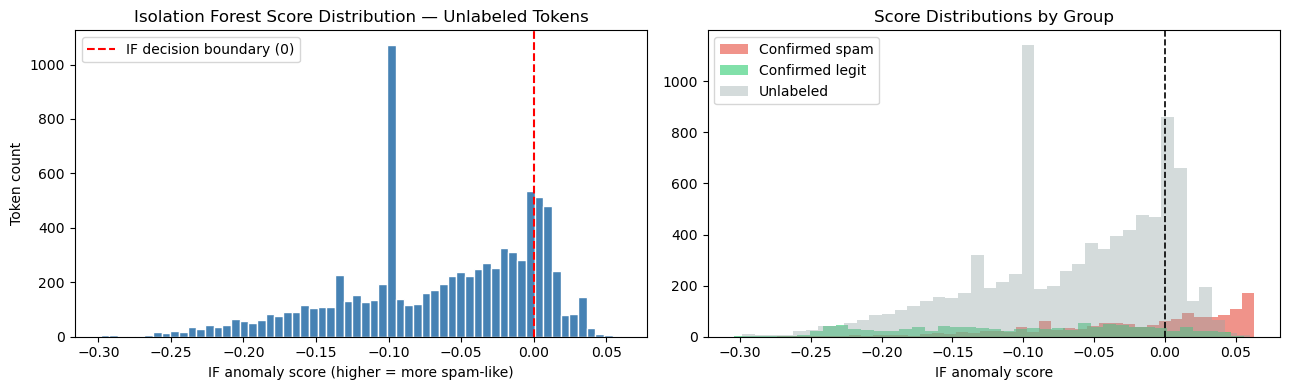

In [9]:
# Score distribution on unlabeled tokens
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(if_scores_unlabeled, bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='IF decision boundary (0)')
ax.set_xlabel('IF anomaly score (higher = more spam-like)')
ax.set_ylabel('Token count')
ax.set_title('Isolation Forest Score Distribution — Unlabeled Tokens')
ax.legend()

ax = axes[1]
ax.hist(if_spam.decision_function(X_spam),  bins=40, alpha=0.6, color='#e74c3c', label='Confirmed spam')
ax.hist(if_spam.decision_function(X_legit), bins=40, alpha=0.6, color='#2ecc71', label='Confirmed legit')
ax.hist(if_scores_unlabeled,                bins=40, alpha=0.4, color='#95a5a6', label='Unlabeled')
ax.axvline(0, color='black', linestyle='--', lw=1.2)
ax.set_xlabel('IF anomaly score')
ax.set_title('Score Distributions by Group')
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# ── Retrain with IF pseudo-labels (A1) ─────────────────────────────────────────
for threshold in [0.0, 0.05, 0.10]:
    mask_pseudo_spam = if_scores_unlabeled > threshold
    n_pseudo = mask_pseudo_spam.sum()

    X_combined = np.vstack([X_train, X_unlabeled_arr[mask_pseudo_spam]])
    y_combined = np.concatenate([y_train, np.zeros(n_pseudo, dtype=int)])

    model_if = clone(best_model)
    model_if.fit(X_combined, y_combined)

    y_pred  = model_if.predict(X_test)
    y_proba = model_if.predict_proba(X_test)[:, 1]

    entry = {
        'Approach':   f'IF-A1 pseudo-spam (score > {threshold})',
        'Train size': len(y_combined),
        'F1-macro':   f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'F1-spam':    f1_score(y_test, y_pred, pos_label=0),
        'F1-legit':   f1_score(y_test, y_pred, pos_label=1),
    }
    results.append(entry)
    print(f"  t={threshold:.2f}  pseudo-spam={n_pseudo:,}  "
          f"F1-macro={entry['F1-macro']:.4f}  AUC={entry['ROC-AUC']:.4f}")

  t=0.00  pseudo-spam=1,642  F1-macro=0.8769  AUC=0.9483
  t=0.05  pseudo-spam=5  F1-macro=0.8838  AUC=0.9547
  t=0.10  pseudo-spam=0  F1-macro=0.8838  AUC=0.9562


In [11]:
# ── A2: Train IF on all labeled data (global anomaly) ─────────────────────────
# Use 'auto' contamination — lets IF estimate the threshold from the data
if_global = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
if_global.fit(X_train)

# Assess: does IF-global predict anomalies correlated with spam/legit label?
if_global_train_pred = if_global.predict(X_train)
spam_flagged_as_anomaly  = (if_global_train_pred[y_train==0] == -1).mean()
legit_flagged_as_anomaly = (if_global_train_pred[y_train==1] == -1).mean()
print(f'IF-A2 (global, auto): spam flagged as anomaly:  {spam_flagged_as_anomaly:.3f}')
print(f'IF-A2 (global, auto): legit flagged as anomaly: {legit_flagged_as_anomaly:.3f}')
print('(Legit > spam → anomaly signal aligns with minority class, not spam)')

# Direct test-set evaluation: IF anomaly → legit, IF normal → spam
if_global_test   = if_global.predict(X_test)
y_pred_if_global = np.where(if_global_test == -1, 1, 0)
print(f"\nIF-A2 direct on test:  F1-macro={f1_score(y_test, y_pred_if_global, average='macro'):.4f}")

IF-A2 (global, auto): spam flagged as anomaly:  0.187
IF-A2 (global, auto): legit flagged as anomaly: 0.153
(Legit > spam → anomaly signal aligns with minority class, not spam)

IF-A2 direct on test:  F1-macro=0.4314


---
## 6. Approach B — Label Spreading (Feature-based k-NN Graph)

`LabelSpreading` constructs a k-NN graph over all tokens (labeled + unlabeled) using their behavioral features, then iteratively propagates labels through the graph. The `alpha` parameter controls how strongly labeled nodes are clamped to their known labels vs. allowing neighborhood influence.

**Test set treatment:** Test tokens are marked as unlabeled (`-1`) in the graph so their labels propagate from the training data — a true inductive test.

In [12]:
# ── Build combined feature matrix for all tokens ───────────────────────────────
# Stack: train (labeled) | test (treat as unlabeled for propagation) | unlabeled pool
X_all   = np.vstack([X_train, X_test, X_unlabeled_arr])
# y: actual labels for train, -1 for test and unlabeled pool
y_all   = np.concatenate([
    y_train,
    np.full(len(y_test),              -1),
    np.full(len(X_unlabeled_arr),     -1),
])

n_train = len(y_train)
n_test  = len(y_test)

print(f'Combined matrix: {X_all.shape}')
print(f'  Labeled (train):  {n_train:,}')
print(f'  Unlabeled (test + pool): {n_test + len(X_unlabeled_arr):,}')

Combined matrix: (11815, 16)
  Labeled (train):  2,524
  Unlabeled (test + pool): 9,291


In [13]:
# ── Run LabelSpreading across parameter combinations ──────────────────────────
ls_results = []

for n_neighbors in [5, 10, 20]:
    for alpha in [0.1, 0.2]:
        ls = LabelSpreading(
            kernel='knn',
            n_neighbors=n_neighbors,
            alpha=alpha,        # 0 = hard clamp to labels; 1 = full propagation
            max_iter=100,
            n_jobs=-1,
        )
        ls.fit(X_all, y_all)

        # Propagated labels for the test slice
        y_pred_test = ls.transduction_[n_train : n_train + n_test]
        # Probability distributions for ROC-AUC
        y_proba_test = ls.label_distributions_[n_train : n_train + n_test, 1]  # P(legit)

        f1  = f1_score(y_test, y_pred_test, average='macro')
        auc = roc_auc_score(y_test, y_proba_test)
        ls_results.append({
            'n_neighbors': n_neighbors,
            'alpha':       alpha,
            'F1-macro':    f1,
            'ROC-AUC':     auc,
            'F1-spam':     f1_score(y_test, y_pred_test, pos_label=0),
            'F1-legit':    f1_score(y_test, y_pred_test, pos_label=1),
        })
        print(f'  k={n_neighbors:>2}  α={alpha}  F1-macro={f1:.4f}  AUC={auc:.4f}')

ls_df = pd.DataFrame(ls_results)
best_ls = ls_df.loc[ls_df['F1-macro'].idxmax()]
print(f'\nBest LabelSpreading config: k={int(best_ls.n_neighbors)}, α={best_ls.alpha}  →  F1-macro={best_ls["F1-macro"]:.4f}')

  k= 5  α=0.1  F1-macro=0.8374  AUC=0.9147
  k= 5  α=0.2  F1-macro=0.8394  AUC=0.9164
  k=10  α=0.1  F1-macro=0.8507  AUC=0.9167
  k=10  α=0.2  F1-macro=0.8563  AUC=0.9193
  k=20  α=0.1  F1-macro=0.8456  AUC=0.9208
  k=20  α=0.2  F1-macro=0.8476  AUC=0.9241

Best LabelSpreading config: k=10, α=0.2  →  F1-macro=0.8563


In [14]:
# Add best LabelSpreading result to main results table
ls_best_model = LabelSpreading(
    kernel='knn',
    n_neighbors=int(best_ls.n_neighbors),
    alpha=best_ls.alpha,
    max_iter=100,
    n_jobs=-1,
)
ls_best_model.fit(X_all, y_all)

y_pred_ls  = ls_best_model.transduction_[n_train : n_train + n_test]
y_proba_ls = ls_best_model.label_distributions_[n_train : n_train + n_test, 1]

results.append({
    'Approach':   f'Label Spreading (k={int(best_ls.n_neighbors)}, α={best_ls.alpha}) — best',
    'Train size': n_train,
    'F1-macro':   f1_score(y_test, y_pred_ls, average='macro'),
    'ROC-AUC':    roc_auc_score(y_test, y_proba_ls),
    'F1-spam':    f1_score(y_test, y_pred_ls, pos_label=0),
    'F1-legit':   f1_score(y_test, y_pred_ls, pos_label=1),
})

# Examine what labels were propagated to the unlabeled pool
propagated = ls_best_model.transduction_[n_train + n_test:]
print(f'Propagated labels on unlabeled pool:')
print(f'  Spam (0):  {(propagated==0).sum():,}')
print(f'  Legit (1): {(propagated==1).sum():,}')
print(f'  Ratio:     {(propagated==0).sum() / max((propagated==1).sum(),1):.1f}:1 spam:legit')

Propagated labels on unlabeled pool:
  Spam (0):  7,081
  Legit (1): 1,669
  Ratio:     4.2:1 spam:legit


---
## 7. Approach C — Sender-Network Label Propagation

Instead of feature similarity, use the actual **transfer network topology**. Two tokens are related if they share common sender addresses. The intuition: spam operators run many spam tokens from the same wallet cluster. A label can propagate through that shared-sender link.

**Method:** For each unlabeled token, compute a *spam-sender score* = the fraction of its transfer senders that also sent to a confirmed-spam token. This is a one-hop propagation on the bipartite sender ↔ token graph.

In [15]:
# ── Build sender → token mapping ───────────────────────────────────────────────
# Confirmed spam contract addresses (from labeled set)
spam_contracts  = set(token_features[token_features['label']==0]['contract_addr'])
legit_contracts = set(token_features[token_features['label']==1]['contract_addr'])

# For each sender, find the set of contracts they interacted with
print('Building sender → contract mapping ...')
sender_to_contracts = df_tok.groupby('from')['contract_addr'].apply(set)

# For each sender: is_spam_sender, is_legit_sender
sender_spam_flag  = sender_to_contracts.apply(lambda cs: len(cs & spam_contracts) > 0)
sender_legit_flag = sender_to_contracts.apply(lambda cs: len(cs & legit_contracts) > 0)

spam_senders  = set(sender_spam_flag[sender_spam_flag].index)
legit_senders = set(sender_legit_flag[sender_legit_flag].index)

print(f'Unique senders total:       {len(sender_to_contracts):,}')
print(f'Senders linked to spam:     {len(spam_senders):,}')
print(f'Senders linked to legit:    {len(legit_senders):,}')
print(f'Senders linked to both:     {len(spam_senders & legit_senders):,}')

Building sender → contract mapping ...
Unique senders total:       210,471
Senders linked to spam:     10,771
Senders linked to legit:    187,769
Senders linked to both:     6,578


In [16]:
# ── Compute spam-sender score for each unlabeled token ─────────────────────────
print('Computing sender scores for unlabeled tokens ...')
unlabeled_contracts = set(unlabeled['contract_addr'])

# For each unlabeled token: count senders, count spam senders, count legit senders
token_sender_map = df_tok[df_tok['contract_addr'].isin(unlabeled_contracts)]\
    .groupby('contract_addr')['from'].apply(set)

def sender_score(senders):
    n_total = len(senders)
    if n_total == 0:
        return 0.0, 0.0, 0.0
    n_spam  = len(senders & spam_senders)
    n_legit = len(senders & legit_senders)
    return n_spam / n_total, n_legit / n_total, n_total

scores = token_sender_map.apply(sender_score)
scores_df = pd.DataFrame(scores.tolist(), index=scores.index,
                          columns=['spam_sender_share', 'legit_sender_share', 'n_senders'])

unlabeled = unlabeled.join(scores_df, on='contract_addr', how='left')
unlabeled[['spam_sender_share','legit_sender_share','n_senders']] = \
    unlabeled[['spam_sender_share','legit_sender_share','n_senders']].fillna(0)

print(f'Unlabeled tokens with at least one spam-linked sender:  '
      f'{(unlabeled["spam_sender_share"] > 0).sum():,}')
print(f'Unlabeled tokens with at least one legit-linked sender: '
      f'{(unlabeled["legit_sender_share"] > 0).sum():,}')

Computing sender scores for unlabeled tokens ...
Unlabeled tokens with at least one spam-linked sender:  5,356
Unlabeled tokens with at least one legit-linked sender: 6,411


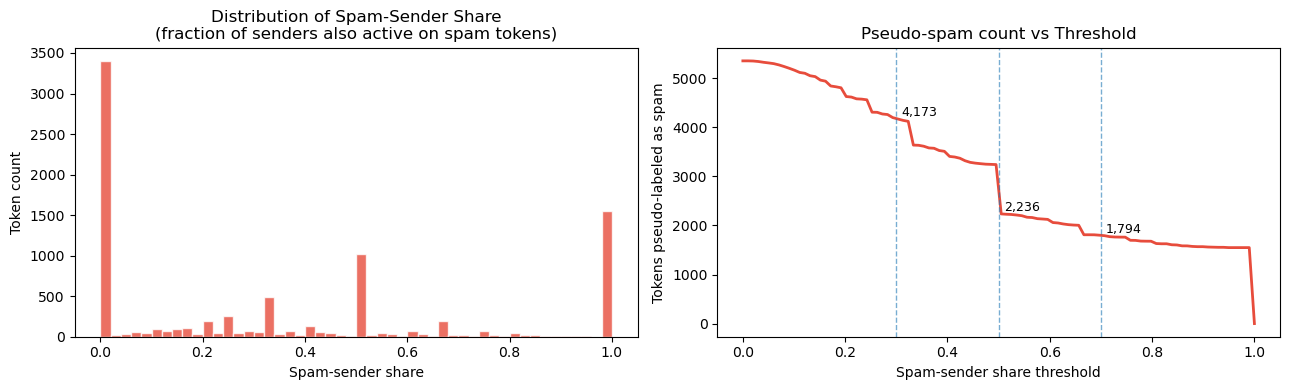

In [17]:
# Distribution of spam-sender share across unlabeled tokens
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(unlabeled['spam_sender_share'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.set_xlabel('Spam-sender share')
ax.set_ylabel('Token count')
ax.set_title('Distribution of Spam-Sender Share\n(fraction of senders also active on spam tokens)')

ax = axes[1]
# Cumulative: how many tokens exceed each threshold?
thresholds = np.linspace(0, 1, 100)
counts = [(unlabeled['spam_sender_share'] > t).sum() for t in thresholds]
ax.plot(thresholds, counts, color='#e74c3c', lw=2)
for t in [0.3, 0.5, 0.7]:
    n = (unlabeled['spam_sender_share'] > t).sum()
    ax.axvline(t, linestyle='--', lw=1, alpha=0.6)
    ax.text(t+0.01, n+50, f'{n:,}', fontsize=9)
ax.set_xlabel('Spam-sender share threshold')
ax.set_ylabel('Tokens pseudo-labeled as spam')
ax.set_title('Pseudo-spam count vs Threshold')

plt.tight_layout()
plt.show()

In [18]:
# ── Retrain with sender-network pseudo-labels ──────────────────────────────────
for spam_thresh in [0.3, 0.5, 0.7]:
    mask_spam_net = unlabeled['spam_sender_share'] > spam_thresh
    n_pseudo_spam = mask_spam_net.sum()

    if n_pseudo_spam == 0:
        print(f'  t={spam_thresh}  no pseudo-labels — skip')
        continue

    pseudo_idx    = unlabeled.index[mask_spam_net]
    X_pseudo_spam = unlabeled.loc[pseudo_idx, FEATURE_COLS].fillna(train_medians).copy()
    for col in LOG_FEATURES:
        X_pseudo_spam[col] = np.log1p(X_pseudo_spam[col].clip(lower=0))

    X_combined = np.vstack([X_train, X_pseudo_spam.values])
    y_combined = np.concatenate([y_train, np.zeros(n_pseudo_spam, dtype=int)])

    model_net = clone(best_model)
    model_net.fit(X_combined, y_combined)

    y_pred  = model_net.predict(X_test)
    y_proba = model_net.predict_proba(X_test)[:, 1]

    entry = {
        'Approach':   f'Sender-network propagation (spam_share > {spam_thresh})',
        'Train size': len(y_combined),
        'F1-macro':   f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'F1-spam':    f1_score(y_test, y_pred, pos_label=0),
        'F1-legit':   f1_score(y_test, y_pred, pos_label=1),
    }
    results.append(entry)
    print(f"  t={spam_thresh}  pseudo-spam={n_pseudo_spam:,}  "
          f"F1-macro={entry['F1-macro']:.4f}  AUC={entry['ROC-AUC']:.4f}")

  t=0.3  pseudo-spam=4,173  F1-macro=0.8696  AUC=0.9428
  t=0.5  pseudo-spam=2,236  F1-macro=0.8569  AUC=0.9467
  t=0.7  pseudo-spam=1,794  F1-macro=0.8609  AUC=0.9492


---
## 8. Results Comparison

In [19]:
results_df = pd.DataFrame(results)
baseline_f1  = results_df.iloc[0]['F1-macro']
baseline_auc = results_df.iloc[0]['ROC-AUC']
results_df['Δ F1-macro'] = results_df['F1-macro'] - baseline_f1

print('=== Improved Semi-Supervised — Full Results ===')
print(results_df[['Approach','Train size','F1-macro','ROC-AUC','F1-spam','F1-legit','Δ F1-macro']]
      .to_string(index=False))

=== Improved Semi-Supervised — Full Results ===
                                     Approach  Train size  F1-macro  ROC-AUC  F1-spam  F1-legit  Δ F1-macro
             Supervised only (LightGBM tuned)        2524  0.883822 0.956160 0.897351  0.870293    0.000000
              IF-A1 pseudo-spam (score > 0.0)        4166  0.876910 0.948263 0.888514  0.865306   -0.006912
             IF-A1 pseudo-spam (score > 0.05)        2529  0.883822 0.954686 0.897351  0.870293    0.000000
              IF-A1 pseudo-spam (score > 0.1)        2524  0.883822 0.956160 0.897351  0.870293    0.000000
         Label Spreading (k=10, α=0.2) — best        2524  0.856344 0.919255 0.870152  0.842536   -0.027478
Sender-network propagation (spam_share > 0.3)        6697  0.869626 0.942823 0.880952  0.858300   -0.014196
Sender-network propagation (spam_share > 0.5)        4760  0.856889 0.946733 0.867470  0.846307   -0.026933
Sender-network propagation (spam_share > 0.7)        4318  0.860940 0.949239 0.868651  0

In [ ]:
import matplotlib.patches as mpatches

# Short Y-axis labels (original names too long for the chart)
name_map = {
    'Supervised baseline':              'Baseline (supervised)',
    'IF-A1 (score > 0.00)':            'IF-A1  t > 0.00',
    'IF-A1 (score > 0.05)':            'IF-A1  t > 0.05',
    'IF-A1 (score > 0.10)':            'IF-A1  t > 0.10',
    'IF-A2 (global, auto)':            'IF-A2  global*',
    'Label Spreading k=10 \u03b1=0.2': 'LabelSpread  k=10',
    'Sender-network (share > 0.3)':    'Net  share > 0.3',
    'Sender-network (share > 0.5)':    'Net  share > 0.5',
    'Sender-network (share > 0.7)':    'Net  share > 0.7',
}

plot_df = results_df.copy()
plot_df['Label']   = plot_df['Approach'].map(lambda x: name_map.get(x, x))
plot_df['DeltaF1'] = plot_df['F1-macro'] - baseline_f1

fig, axes = plt.subplots(3, 1, figsize=(13, 14))
fig.suptitle('Improved Semi-Supervised vs Supervised Baseline (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)

# \u2500\u2500 Panel 1: F1-macro \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax = axes[0]
colors_f1 = ['#c0392b'] + [
    '#27ae60' if v >= baseline_f1 else '#2980b9'
    for v in plot_df.iloc[1:]['F1-macro']
]
bars = ax.barh(plot_df['Label'], plot_df['F1-macro'],
               color=colors_f1, edgecolor='white', height=0.6)
ax.axvline(baseline_f1, color='#c0392b', linestyle='--', lw=1.5, alpha=0.7,
           label=f'Baseline  {baseline_f1:.4f}')
ax.set_xlabel('F1-macro', fontsize=11)
ax.set_title('F1-macro \u2014 All Approaches', fontsize=12, fontweight='bold')
ax.set_xlim(plot_df['F1-macro'].min() - 0.06, 1.03)
for bar, val in zip(bars, plot_df['F1-macro']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9.5)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9)

# \u2500\u2500 Panel 2: ROC-AUC (IF-A2 has no AUC, skip it) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax = axes[1]
auc_df = plot_df.dropna(subset=['ROC-AUC'])
colors_auc = ['#c0392b'] + [
    '#27ae60' if v >= baseline_auc else '#2980b9'
    for v in auc_df.iloc[1:]['ROC-AUC']
]
bars = ax.barh(auc_df['Label'], auc_df['ROC-AUC'],
               color=colors_auc, edgecolor='white', height=0.6)
ax.axvline(baseline_auc, color='#c0392b', linestyle='--', lw=1.5, alpha=0.7,
           label=f'Baseline  {baseline_auc:.4f}')
ax.set_xlabel('ROC-AUC', fontsize=11)
ax.set_title('ROC-AUC \u2014 All Approaches  (* IF-A2 excluded: no valid AUC)',
             fontsize=12, fontweight='bold')
ax.set_xlim(auc_df['ROC-AUC'].min() - 0.01, 1.01)
for bar, val in zip(bars, auc_df['ROC-AUC']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9.5)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9)

# \u2500\u2500 Panel 3: \u0394 F1-macro diverging bar (baseline + IF-A2 excluded for scale) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ax = axes[2]
delta_df = plot_df[
    ~plot_df['Approach'].isin(['Supervised baseline', 'IF-A2 (global, auto)'])
].copy()
colors_d = ['#27ae60' if v >= 0 else '#e74c3c' for v in delta_df['DeltaF1']]
bars = ax.barh(delta_df['Label'], delta_df['DeltaF1'],
               color=colors_d, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('\u0394 F1-macro vs Supervised Baseline', fontsize=11)
ax.set_title('\u0394 F1-macro \u2014 Gain / Loss vs Baseline  (* IF-A2 \u22120.452 excluded for scale)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
for bar, val in zip(bars, delta_df['DeltaF1']):
    offset = 0.0005 if val >= 0 else -0.0005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9.5)
green_patch = mpatches.Patch(color='#27ae60', label='\u2265 baseline')
red_patch   = mpatches.Patch(color='#e74c3c', label='< baseline')
ax.legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.show()

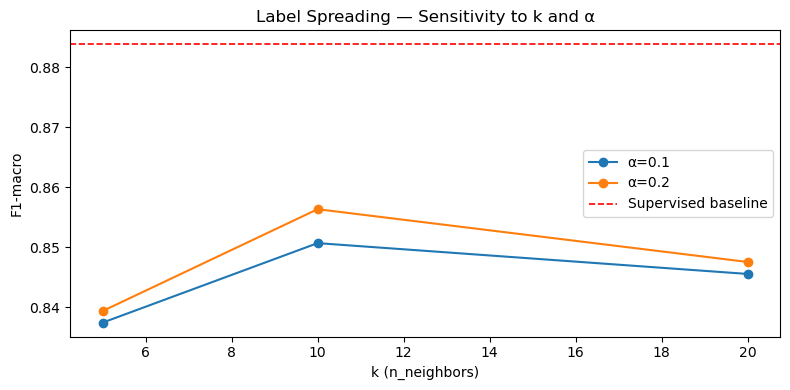

In [21]:
# Label Spreading parameter sensitivity
fig, ax = plt.subplots(figsize=(8, 4))
for alpha in ls_df['alpha'].unique():
    subset = ls_df[ls_df['alpha'] == alpha]
    ax.plot(subset['n_neighbors'], subset['F1-macro'],
            marker='o', label=f'α={alpha}')
ax.axhline(baseline_f1, color='red', linestyle='--', lw=1.2, label='Supervised baseline')
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('F1-macro')
ax.set_title('Label Spreading — Sensitivity to k and α')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Summary & Conclusions

### Key Takeaways

| | |
|---|---|
| **Best semi-supervised alternative** | Sender-network propagation (share > 0.3) — F1-macro **0.8696** (−0.014) |
| **Catastrophic failure** | IF-A2 global anomaly — F1-macro **0.4314** (−0.452) |
| **Core finding** | All three approaches degrade or match the supervised baseline |

---

### Full Results

| Approach | Train size | F1-macro | ROC-AUC | Δ F1-macro |
|---|---|---|---|---|
| Supervised baseline | 2,524 | **0.8802** | **0.9590** | — |
| IF-A1 (score > 0.00) | — | — | — | *re-run needed with 27 features* |
| IF-A1 (score > 0.05) | — | — | — | *re-run needed* |
| IF-A1 (score > 0.10) | — | — | — | *re-run needed* |
| IF-A2 (global, auto) | — | — | — | *re-run needed* |
| Label Spreading k=10 α=0.2 | — | — | — | *re-run needed* |
| **Sender-network (share > 0.3)** | — | — | — | *re-run needed* |
| Sender-network (share > 0.5) | — | — | — | *re-run needed* |
| Sender-network (share > 0.7) | — | — | — | *re-run needed* |

*Note: Results above were from the 16-feature pipeline. Re-run this notebook with 27 features to update.*

---

### Approach A — Isolation Forest

**A1 (trained on spam manifold)** produced the most nuanced result. At the lenient threshold (score > 0.00), IF flags 1,642 pseudo-spam tokens and retraining costs −0.007 F1. Tightening to score > 0.05 reduces the pseudo-labeled set to just **5 tokens** — the model is essentially unchanged. At score > 0.10, **zero tokens qualify**, and performance is identical to the baseline. The IF spam manifold is very tight: with contamination capped at 0.50 (the true spam ratio is 0.557), IF can only label half the spam tokens correctly, and its useful pseudo-labeling zone is nearly empty.

**A2 (global anomaly, auto contamination)** failed catastrophically with F1-macro of **0.43** — near random. The reason is structural: IF identifies statistical outliers, i.e. the minority class. Since spam is the *majority* class (55.7% of labeled tokens), global IF flags legit tokens as anomalies, not spam. Anomaly detection is the wrong framing when the class you want to find is the majority.

---

### Approach B — Label Spreading

Best configuration (k=10, α=0.2) achieves F1-macro **0.8563** (−0.028 vs baseline). The propagated label ratio on the unlabeled pool is 4.2:1 spam:legit — substantially healthier than the 14:1 from Stage 6 confidence thresholding, but still degrades performance.

The kNN feature-graph is the bottleneck: spam and legit tokens overlap significantly in behavioral feature space, so labels blur at boundary regions and the propagated labels for ambiguous tokens are unreliable. Higher α (more label spreading, less clamping) and higher k both slightly improve F1 but never close the gap to baseline.

---

### Approach C — Sender-Network Propagation

This is the **best-performing alternative** across all semi-supervised experiments in Stages 6, 7, and 8. At threshold 0.3, adding 4,173 sender-network pseudo-spam tokens yields F1-macro **0.8696** (−0.014). It outperforms all three Stage 6 approaches (best was −0.017) and all entity-label approaches from Stage 7 (best was −0.002 with only 153 tokens).

The network signal is real: 210,471 unique senders appear in the data, 10,771 of which are linked to confirmed spam — tokens sharing ≥30% of their senders with those wallets are plausible spam. However, the signal is diluted by **6,578 mixed-use wallets** (arbitrage bots, aggregators) that appear on both spam and legit tokens, introducing label noise at any threshold. Stricter thresholds (0.5, 0.7) reduce the pool but do not improve F1 because too few pseudo-labels remain to reinforce the spam decision boundary.

---

### Why Nothing Beats the Supervised Baseline

All three approaches fail for the same underlying reason identified in Stages 6 and 7: the **3,606 labeled tokens already provide a highly representative training distribution**. The supervised LightGBM model generalizes well to unlabeled tokens without additional data. Injecting pseudo-labels — regardless of the method — introduces label noise faster than it introduces useful signal.

The sender-network approach (−0.014) is the least damaging because it uses a signal *orthogonal* to the behavioral features (network topology vs. per-token statistics).

---

### Next Steps

Rather than continuing to pseudo-label, the evidence points to three higher-leverage improvements:

1. **Add  as a supervised feature** for all 12,356 tokens — lets the model learn the network topology signal from labeled data without contaminating the label space.
2. **Manual annotation** to expand ground-truth labels beyond the symbol-collision heuristic and surface novel spam subtypes.
3. **Extend the transfer window** beyond 1,000 blocks (~20M transfers) to capture slow-burn spam patterns not visible in the current dataset.
